# EmbeddingGemma-2: Multimodal retrieval in one vector space

[EmbeddingGemma-2](https://huggingface.co/google/embeddinggemma-2) is an open (Apache 2.0) embedding model from Google DeepMind. It maps **text, code, images, video, and audio** into the same 768-dimensional space, so a text query, a photo, a sound clip, and a video can all be compared with one cosine similarity.

This notebook runs real retrieval tasks on public data:

| # | Demo | Query → index |
|---|---|---|
| 1 | One space for every modality | text ↔ photo ↔ sound |
| 2 | Photo search | text → 1,000 photos (with Recall@1) |
| 3 | Any language, or a photo as the query | German / Spanish / photo → photos |
| 4 | Ask with your voice | spoken question → photos, no transcription |
| 5 | Sound search | text → 50 environmental sounds |
| 6 | Video moments finder | text → timestamps in a 5-minute video |
| 7 | PDF pages without OCR | text → page images |
| 8 | Matryoshka: smaller vectors | recall at 768 / 512 / 256 / 128 dims |
| 9 | Load only what you need | 270M text-only queries against the full index |

**Runtime:** a free T4 GPU works (Runtime → Change runtime type → T4 GPU). The whole notebook takes about 15 minutes on a T4, mostly embedding the 1,000 photos (about 8 minutes).

## 0. Setup

In [1]:
!pip install -q -U "sentence-transformers[image,video]>=6.1.0" transformers torchcodec gTTS pymupdf

Two install gotchas this line avoids:
- **No `[audio]` extra.** It pulls in `transformers[audio]` → `pyctcdecode`, which pins `numpy<2`. On Colab's Python 3.13 there's no prebuilt NumPy 1.x, so pip spends minutes compiling it and downgrades NumPy. Audio works without the extra: Colab already ships `librosa` and `soundfile`, which are all the model needs to load audio files.
- **Add `torchcodec` yourself.** Video decoding needs it (newer torchvision removed `read_video`), and the `[video]` extra doesn't install it. It needs torch 2.11 or newer, which Colab has.

In [2]:
import torch
from sentence_transformers import SentenceTransformer

MODEL_ID = "google/embeddinggemma-2"

if torch.cuda.is_available():
    device = "cuda"
    # bfloat16 needs an Ampere-or-newer GPU (compute capability >= 8). A T4 is 7.5, so it gets float32.
    dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float32
elif torch.backends.mps.is_available():
    device, dtype = "mps", torch.float32
else:
    device, dtype = "cpu", torch.float32

# Never use float16 with this model: its activations overflow fp16 and you get NaN or
# silently wrong embeddings, with no error (see the model card).
model = SentenceTransformer(MODEL_ID, device=device, model_kwargs={"torch_dtype": dtype})
print(f"{device} / {dtype} / {sum(p.numel() for p in model.parameters())/1e6:.0f}M parameters")

modules.json:   0%|          | 0.00/413 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/1.56k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/21.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/97.0 [00:00<?, ?B/s]

cuda / torch.float32 / 744M parameters


### Download the demo data
All public datasets, about 230 MB in total:
- **Flickr30k 1k test split**: 1,000 photos with 5 human captions each ([nlphuji/flickr_1k_test_image_text_retrieval](https://huggingface.co/datasets/nlphuji/flickr_1k_test_image_text_retrieval))
- **ESC-50**: one clip from each of 50 environmental sound classes ([karolpiczak/ESC-50](https://github.com/karolpiczak/ESC-50), CC BY-NC 3.0)
- **Big Buck Bunny**: the Blender open movie, first 5 minutes ([peach.blender.org](https://peach.blender.org), CC BY 3.0)
- **"Attention Is All You Need"**: the arXiv PDF, rendered to page images

In [3]:
import csv, json, os, subprocess, urllib.request, zipfile
from pathlib import Path
from huggingface_hub import hf_hub_download

DATA = Path("data"); DATA.mkdir(exist_ok=True)

def fetch(url, dest):
    dest = Path(dest)
    if not dest.exists():
        dest.write_bytes(urllib.request.urlopen(urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})).read())   # arXiv blocks the default urllib agent
    return dest

# Flickr 1k photos + captions
REPO = "nlphuji/flickr_1k_test_image_text_retrieval"
if not (DATA / "images_flickr_1k_test").exists():
    z = hf_hub_download(REPO, "images_flickr_1k_test.zip", repo_type="dataset")
    zipfile.ZipFile(z).extractall(DATA)
cap_csv = hf_hub_download(REPO, "test_1k_flickr.csv", repo_type="dataset")

# ESC-50: first clip of each class
ESC = "https://raw.githubusercontent.com/karolpiczak/ESC-50/master"
fetch(f"{ESC}/meta/esc50.csv", DATA / "esc50.csv")
(DATA / "esc50").mkdir(exist_ok=True)
esc_first = {}
for r in csv.DictReader(open(DATA / "esc50.csv")):
    esc_first.setdefault(r["category"], r["filename"])
for f in esc_first.values():
    fetch(f"{ESC}/audio/{f}", DATA / "esc50" / f)

# Big Buck Bunny (320x180) and the Attention paper
if not (DATA / "BigBuckBunny_320x180.mp4").exists():
    z = fetch("https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4.zip", DATA / "bbb.zip")
    zipfile.ZipFile(z).extractall(DATA); os.remove(z)
fetch("https://arxiv.org/pdf/1706.03762", DATA / "attention.pdf")
print("data ready")

images_flickr_1k_test.zip: reconstructing file:   0%|          |  0.00B /  141MB            

images_flickr_1k_test.zip: downloading bytes:           |  0.00B            

test_1k_flickr.csv: reconstructing file:   0%|          |  0.00B / 1.13MB            

test_1k_flickr.csv: downloading bytes:           |  0.00B            

data ready


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Audio, display

rows = list(csv.DictReader(open(cap_csv)))
photo_paths = [str(DATA / "images_flickr_1k_test" / r["filename"]) for r in rows]
captions = [json.loads(r["raw"]) for r in rows]          # 5 captions per photo

def show_images(paths, titles=None, size=3.2):
    fig, axes = plt.subplots(1, len(paths), figsize=(size * len(paths), size))
    for i, (ax, p) in enumerate(zip(np.atleast_1d(axes), paths)):
        ax.imshow(Image.open(p) if isinstance(p, (str, Path)) else p); ax.axis("off")
        if titles: ax.set_title(titles[i], fontsize=9)
    plt.tight_layout(); plt.show()

def top_k(query_emb, index_emb, k=5):
    scores = model.similarity(query_emb, index_emb)[0]
    best = scores.argsort(descending=True)[:k]
    return [(int(i), float(scores[i])) for i in best]

## 1. One space for every modality

Six concepts, each as a **sentence**, a **photo**, and a **sound**. If the encoders share one space, the matching pairs should score highest, which shows up as a bright diagonal in each heatmap. The third heatmap is the hardest test: it compares photos with sounds directly, with no text anywhere in between.

Note the rules for prompts: **text gets a task prompt, media gets none.**

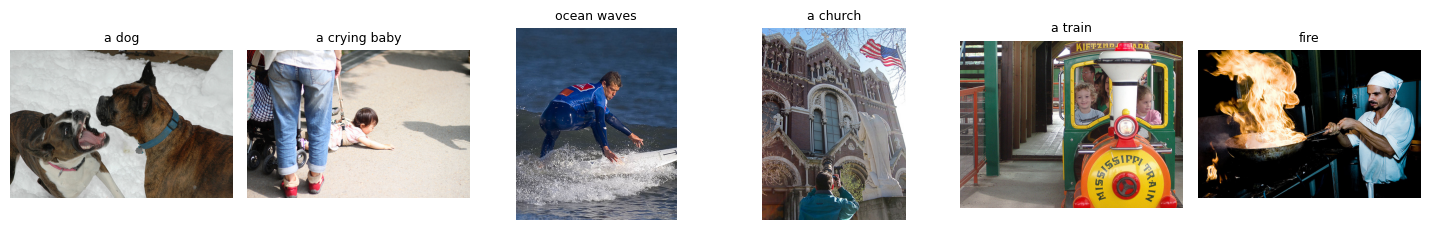

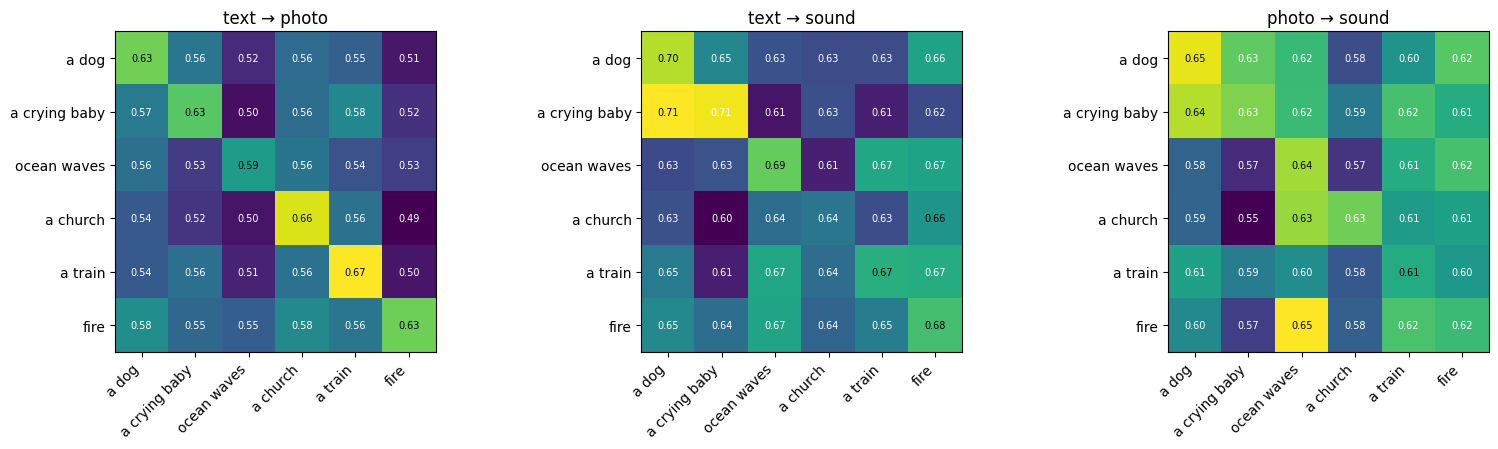

In [5]:
concepts = {'a dog': ['3348384389.jpg', 'dog'], 'a crying baby': ['4709819574.jpg', 'crying_baby'], 'ocean waves': ['2978409165.jpg', 'sea_waves'], 'a church': ['4495033915.jpg', 'church_bells'], 'a train': ['2975845158.jpg', 'train'], 'fire': ['2709044515.jpg', 'crackling_fire']}  # concept -> (photo filename, ESC-50 class)
names = list(concepts)

text_emb  = model.encode([f"a photo or sound of {c}" for c in names], prompt_name="SearchQuery")
photo_emb = model.encode([{"image": str(DATA / "images_flickr_1k_test" / concepts[c][0])} for c in names])
sound_emb = model.encode([{"audio": str(DATA / "esc50" / esc_first[concepts[c][1]])} for c in names])

show_images([DATA / "images_flickr_1k_test" / concepts[c][0] for c in names], names, size=2.4)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (a, b, title) in zip(axes, [(text_emb, photo_emb, "text → photo"),
                                    (text_emb, sound_emb, "text → sound"),
                                    (photo_emb, sound_emb, "photo → sound")]):
    s = model.similarity(a, b).float().numpy()
    ax.imshow(s, cmap="viridis"); ax.set_title(title)
    ax.set_xticks(range(len(names)), names, rotation=45, ha="right"); ax.set_yticks(range(len(names)), names)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{s[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="black" if s[i, j] == s[i].max() else "white")
plt.tight_layout(); plt.show()

What to notice:
- **text → photo** is a clean diagonal: every sentence finds its photo (the row maximum is in black text).
- **text → sound** gets most of them right, and **photo → sound** is the noisiest. The pairs that involve non-speech sound are the weakest link, and you'll see that again in section 5.
- The scores themselves are compressed into a narrow band. Cosine scores from an embedding model are only meaningful **relative to each other**. Rank by them and don't use a fixed threshold like "> 0.8 means a match" without calibrating it on your own data.

## 2. Search 1,000 photos with text

Embed every photo once (that's the index), then each query is one text embedding and one matrix multiply. This is the slow part: about 8 minutes on a T4.

In [6]:
photo_index = model.encode([{"image": p} for p in photo_paths], batch_size=16, show_progress_bar=True)
photo_index.shape

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

(1000, 768)

a dog catching a frisbee


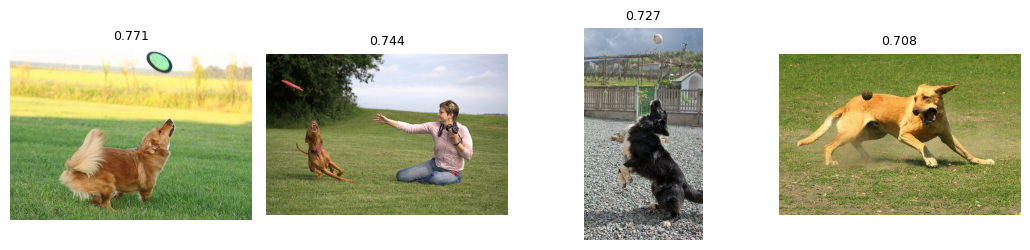

people dancing at a wedding


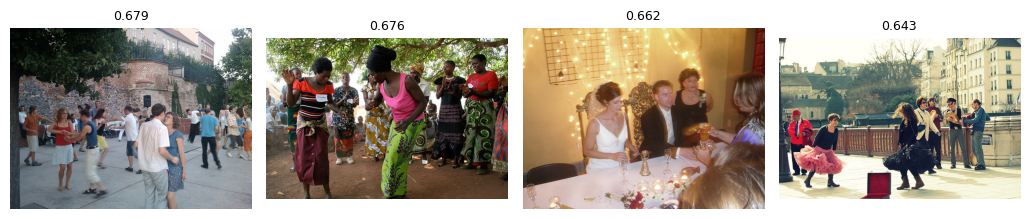

a man fixing a bicycle


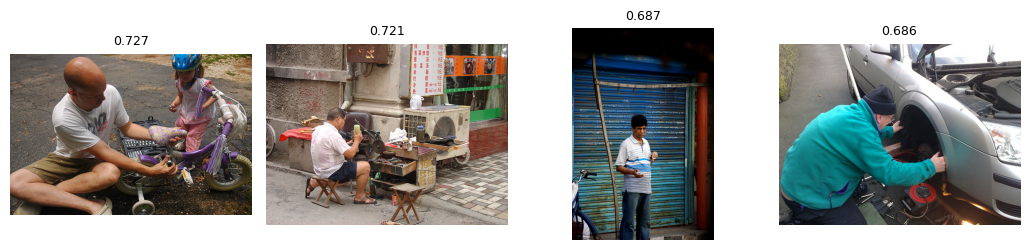

kids playing in the snow


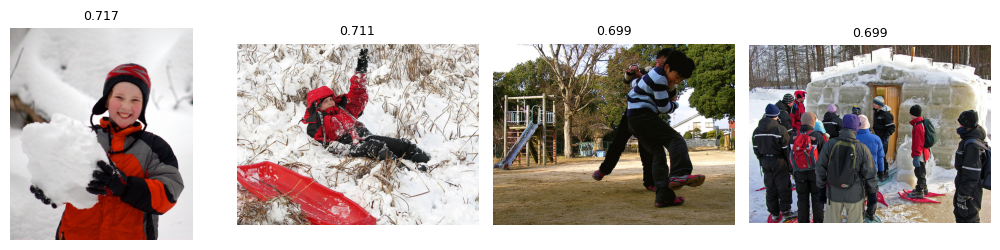

In [7]:
for q in ["a dog catching a frisbee", "people dancing at a wedding", "a man fixing a bicycle", "kids playing in the snow"]:
    hits = top_k(model.encode(q, prompt_name="SearchQuery"), photo_index, k=4)
    print(q); show_images([photo_paths[i] for i, _ in hits], [f"{s:.3f}" for _, s in hits], size=2.6)

### How good is it? Measure it.
Flickr gives us 5,000 human captions, each written for exactly one of the 1,000 photos. For every caption, check whether its own photo ranks first (Recall@1) or in the top 5 (Recall@5).

In [8]:
all_caps = [c for caps in captions for c in caps]
cap_owner = np.array([i for i, caps in enumerate(captions) for _ in caps])
cap_emb = model.encode(all_caps, prompt_name="SearchQuery", batch_size=64, show_progress_bar=True)

def recall_at(q_emb, idx_emb, owner, ks=(1, 5)):
    s = model.similarity(q_emb, idx_emb)
    ranks = s.argsort(dim=1, descending=True)[:, :max(ks)].numpy()
    return {f"R@{k}": float(np.mean([owner[i] in ranks[i, :k] for i in range(len(owner))])) for k in ks}

print("text → photo:", recall_at(cap_emb, photo_index, cap_owner))

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

text → photo: {'R@1': 0.8636, 'R@5': 0.975}


## 3. Any language, or a photo as the query

The text side understands 100+ languages, and the query doesn't have to be text at all.

ein Hund, der im Schnee rennt


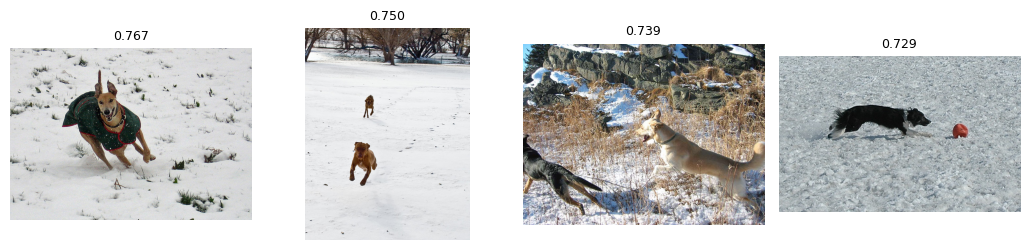

una mujer tocando la guitarra


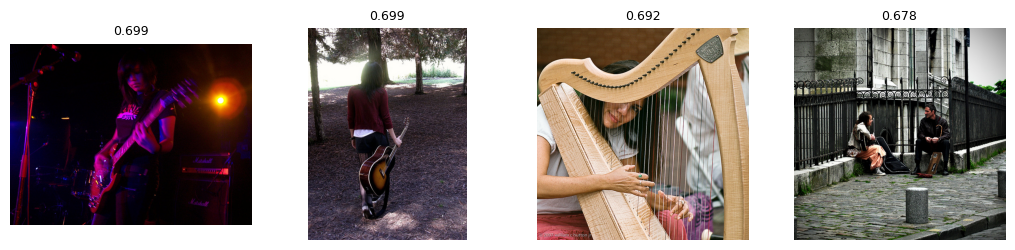

In [9]:
for q in ["ein Hund, der im Schnee rennt", "una mujer tocando la guitarra"]:   # German, Spanish
    hits = top_k(model.encode(q, prompt_name="SearchQuery"), photo_index, k=4)
    print(q); show_images([photo_paths[i] for i, _ in hits], [f"{s:.3f}" for _, s in hits], size=2.6)

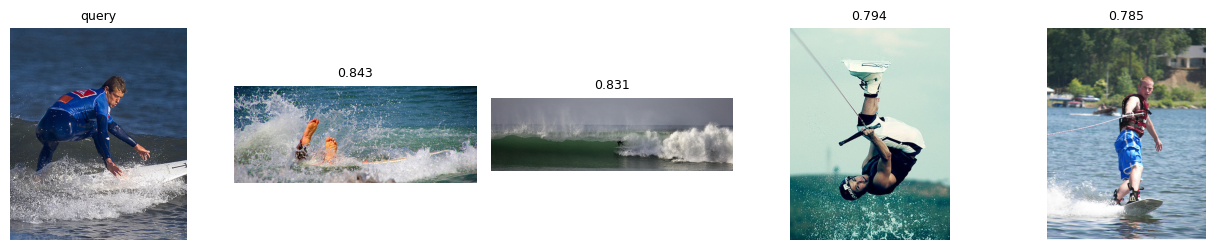

In [10]:
query_photo = photo_paths[319]
hits = top_k(photo_index[319:319 + 1], photo_index, k=5)[1:]   # skip itself
show_images([query_photo] + [photo_paths[i] for i, _ in hits], ["query"] + [f"{s:.3f}" for _, s in hits], size=2.6)

## 4. Ask with your voice

The old way: speech-to-text, then embed the transcript. Here the **audio itself** is the query. We synthesize a spoken question with gTTS (Google Translate's TTS) so the cell runs anywhere, but any 16 kHz mono recording works, including your own voice memo.

spoken: 'a dog jumping into a lake'  (same photos as the typed query: 4/4)


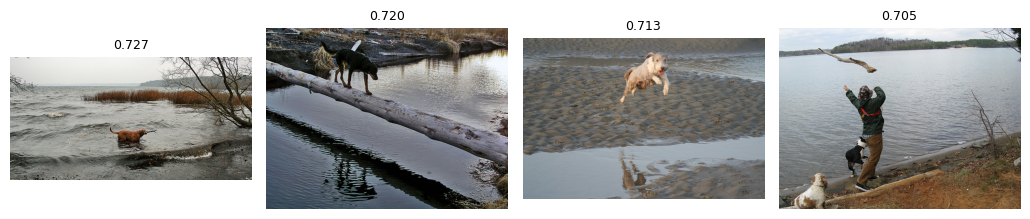

spoken: 'a little girl on a swing'  (same photos as the typed query: 4/4)


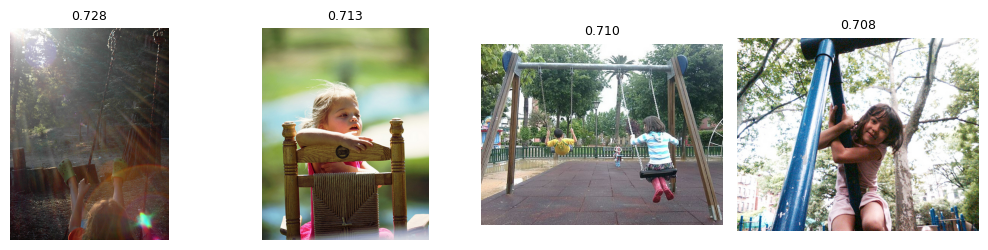

In [11]:
from gtts import gTTS
import librosa, soundfile as sf

def speak(text, path):
    mp3 = path.with_suffix(".mp3"); gTTS(text).save(mp3)
    wav, _ = librosa.load(mp3, sr=16000, mono=True)       # the model expects 16 kHz mono
    sf.write(path, wav, 16000); return str(path)

for q in ["a dog jumping into a lake", "a little girl on a swing"]:
    clip = speak(q, DATA / f"voice_{q[:12].replace(' ', '_')}.wav")
    display(Audio(clip))
    hits = top_k(model.encode({"audio": clip}), photo_index, k=4)
    typed = top_k(model.encode(q, prompt_name="SearchQuery"), photo_index, k=4)
    print(f"spoken: {q!r}  (same photos as the typed query: {len({i for i, _ in hits} & {i for i, _ in typed})}/4)")
    show_images([photo_paths[i] for i, _ in hits], [f"{s:.3f}" for _, s in hits], size=2.6)

The spoken query never becomes text, yet it lands on almost the same photos as the typed sentence. The audio encoder is strongest on **speech**, which makes voice search, meeting recordings, and voice memos a natural fit.

## 5. Search sounds with text

Speech is one thing; what about non-speech sounds? Here are fifty environmental sounds (dog, rain, chainsaw, church bells…), one clip each. For every class name, does its own clip come back first? That's zero-shot audio classification with no training, and it's a harder test than it looks: some clips are quiet, short, or ambiguous.

In [12]:
classes = list(esc_first)
sound_index = model.encode([{"audio": str(DATA / "esc50" / esc_first[c])} for c in classes], batch_size=8)
label_emb = model.encode([f"the sound of {c.replace('_', ' ')}" for c in classes], prompt_name="SearchQuery")

ranks = model.similarity(label_emb, sound_index).argsort(dim=1, descending=True).numpy()
print(f"top-1: {(ranks[:, 0] == np.arange(len(classes))).mean():.0%}   top-5: {np.mean([i in ranks[i, :5] for i in range(len(classes))]):.0%}   (chance: 2% / 10%)")
print("hits:", [c for i, c in enumerate(classes) if ranks[i, 0] == i])

top-1: 24%   top-5: 56%   (chance: 2% / 10%)
hits: ['chirping_birds', 'vacuum_cleaner', 'clapping', 'church_bells', 'wind', 'crackling_fire', 'insects', 'laughing', 'hen', 'breathing', 'toilet_flush', 'clock_tick']


In [13]:
sound_queries = ['a crackling campfire', 'someone laughing', 'a toilet flushing', 'a dog barking', 'rain falling']
for q in sound_queries:
    hits = top_k(model.encode(q, prompt_name="SearchQuery"), sound_index, k=3)
    print(f"{q:22} → " + ", ".join(f"{classes[i]} ({s:.3f})" for i, s in hits))

i, _ = top_k(model.encode(sound_queries[0], prompt_name="SearchQuery"), sound_index, k=1)[0]
print("playing the top hit for", repr(sound_queries[0]))
display(Audio(str(DATA / "esc50" / esc_first[classes[i]])))

a crackling campfire   → crackling_fire (0.665), crickets (0.664), rain (0.663)
someone laughing       → laughing (0.785), coughing (0.755), breathing (0.735)
a toilet flushing      → toilet_flush (0.720), rain (0.668), pouring_water (0.667)
a dog barking          → crow (0.744), dog (0.732), hen (0.723)
rain falling           → wind (0.701), helicopter (0.685), sea_waves (0.676)
playing the top hit for 'a crackling campfire'


Far above chance, but well below what the photo search showed. Our takeaway: **speech is the audio encoder's strength; general sound events are its weak spot**. If sound-event search matters to you, test on your own clips before you rely on it.

## 6. Video moments finder

Cut the first 5 minutes of Big Buck Bunny into 5-second chunks and embed each chunk as a video (the model samples **1 frame per second** by default, 140 tokens per frame). A text query then returns timestamps.

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

a bird stretching its wings on a branch


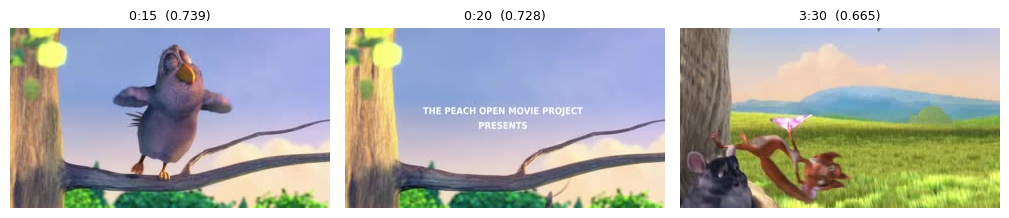

a dark hole in the ground


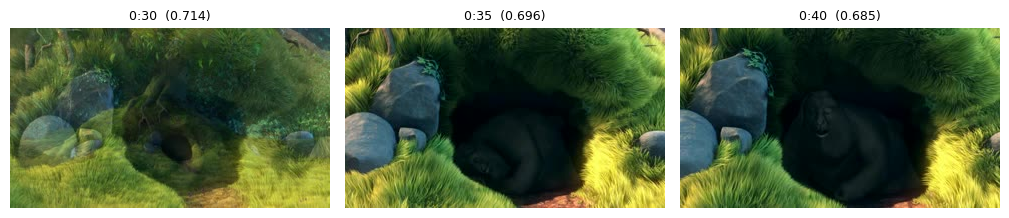

a giant rabbit smelling a white flower


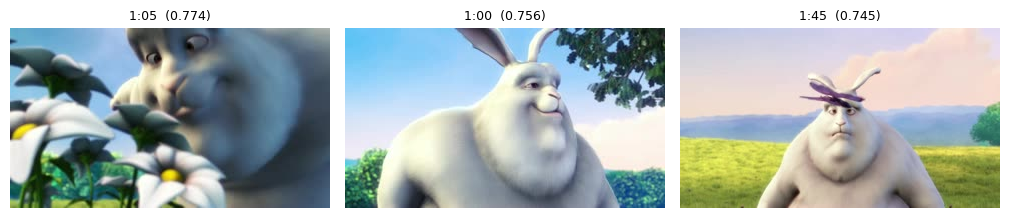

a purple butterfly


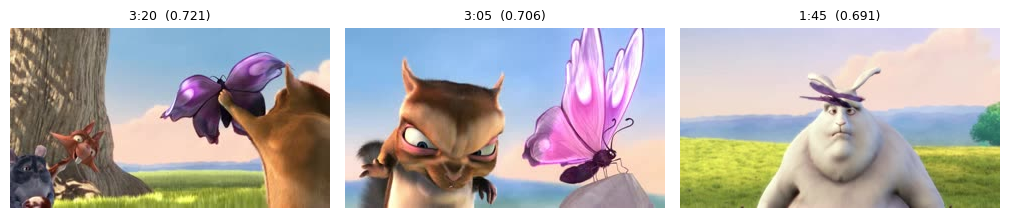

an apple lying in the grass


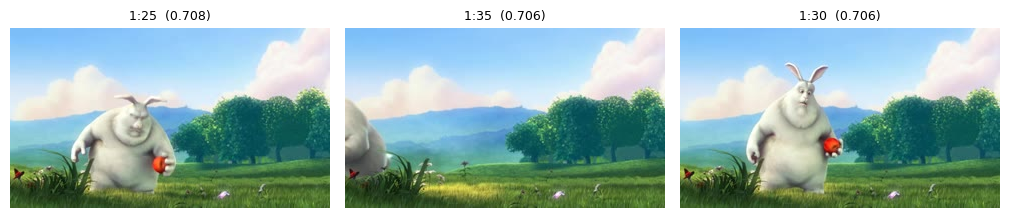

In [14]:
CHUNK, MINUTES = 5, 5
(DATA / "chunks").mkdir(exist_ok=True)
starts = list(range(0, MINUTES * 60, CHUNK))
chunk_paths = []
for s in starts:
    out = DATA / "chunks" / f"chunk_{s:04d}.mp4"
    if not out.exists():
        subprocess.run(["ffmpeg", "-v", "error", "-y", "-ss", str(s), "-t", str(CHUNK), "-i",
                        str(DATA / "BigBuckBunny_320x180.mp4"), "-an", "-c:v", "libx264", str(out)], check=True)
    chunk_paths.append(str(out))

video_index = model.encode([{"video": p} for p in chunk_paths], batch_size=4, show_progress_bar=True)

def frame_at(t):
    out = DATA / "frame.jpg"
    subprocess.run(["ffmpeg", "-v", "error", "-y", "-ss", str(t), "-i", str(DATA / "BigBuckBunny_320x180.mp4"),
                    "-frames:v", "1", str(out)], check=True)
    return Image.open(out).copy()

for q in ['a bird stretching its wings on a branch', 'a dark hole in the ground', 'a giant rabbit smelling a white flower', 'a purple butterfly', 'an apple lying in the grass']:
    hits = top_k(model.encode(q, prompt_name="SearchQuery"), video_index, k=3)
    print(q)
    show_images([frame_at(starts[i] + CHUNK / 2) for i, _ in hits],
                [f"{starts[i]//60}:{starts[i]%60:02d}  ({s:.3f})" for i, s in hits], size=3.4)

## 7. Search PDF pages without OCR

Render each page of "Attention Is All You Need" to an image and embed the **picture of the page**. The vision encoder reads layout, figures, and tables directly, with no text extraction.

Pages are dense, so this is where the **vision token budget** matters. By default an image costs 280 tokens; you can raise it (up to 1,120) for fine detail at the cost of speed and context.

'diagram of the transformer model architecture with encoder and decoder stacks'
   top page @280 tokens: 3   @1120 tokens: 3


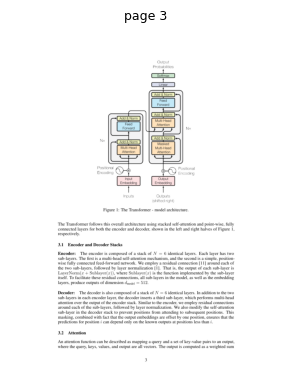

'scaled dot-product attention and multi-head attention diagrams'
   top page @280 tokens: 4   @1120 tokens: 4


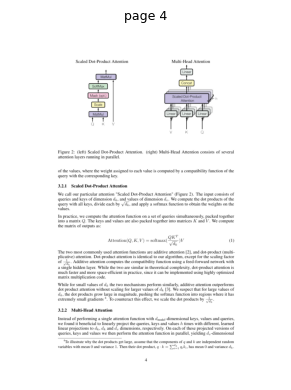

'positional encoding with sine and cosine functions'
   top page @280 tokens: 6   @1120 tokens: 6


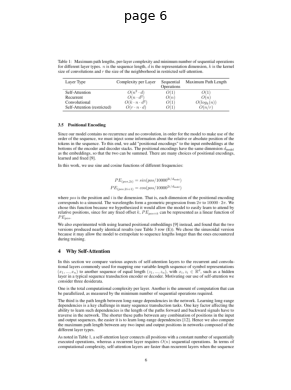

'table comparing BLEU scores and training cost of translation models'
   top page @280 tokens: 8   @1120 tokens: 8


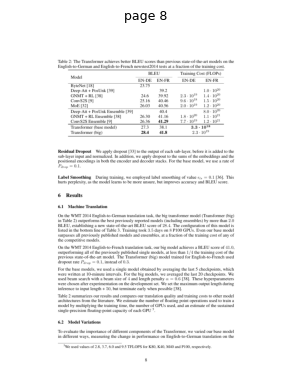

'visualization of attention heads attending to words in a sentence'
   top page @280 tokens: 13   @1120 tokens: 15


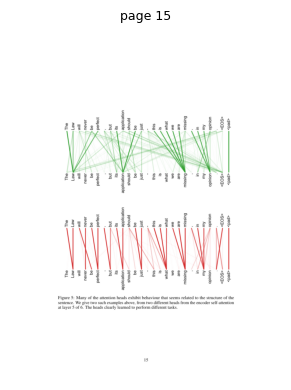

In [15]:
import pymupdf
pdf = pymupdf.open(DATA / "attention.pdf")
page_paths = []
for n, page in enumerate(pdf, start=1):
    out = DATA / f"page_{n:02d}.png"; page.get_pixmap(dpi=110).save(out); page_paths.append(str(out))

image_processor = model[0].processor.image_processor
page_index = {}
for budget in (280, 1120):
    image_processor.max_soft_tokens = budget
    page_index[budget] = model.encode([{"image": p} for p in page_paths], batch_size=2)
image_processor.max_soft_tokens = 280        # back to the default for the rest of the notebook

for q in ['diagram of the transformer model architecture with encoder and decoder stacks', 'scaled dot-product attention and multi-head attention diagrams', 'positional encoding with sine and cosine functions', 'table comparing BLEU scores and training cost of translation models', 'visualization of attention heads attending to words in a sentence']:
    q_emb = model.encode(q, prompt_name="SearchQuery")
    best = {b: top_k(q_emb, page_index[b], k=1)[0][0] + 1 for b in page_index}
    print(f"{q!r}\n   top page @280 tokens: {best[280]}   @1120 tokens: {best[1120]}")
    show_images([page_paths[best[1120] - 1]], [f"page {best[1120]}"], size=4)

On this paper the default 280-token budget already finds the right pages; 1,120 tokens took about 9x longer to embed without changing much. Raise the budget when you need **fine detail** inside a page (small numbers, dense tables), not for finding which page a figure is on.

## 8. Matryoshka: how small can the vectors get?

EmbeddingGemma 2 is trained so the **first** 512, 256, or 128 numbers of each vector still work as an embedding on their own. Smaller vectors mean a smaller index (768 → 128 is 6x less storage). The model card says text barely notices but multimodal retrieval drops at 128. Let's check on our own data.

Two rules: **re-normalize after truncating** (`normalize_embeddings=True` does it), and **queries and index must use the same size**.

In [16]:
def truncate(e, d):
    e = np.asarray(e)[:, :d]
    return e / np.linalg.norm(e, axis=1, keepdims=True)    # re-normalize, or cosine scores drift silently

for d in (768, 512, 256, 128):
    r = recall_at(truncate(cap_emb, d), truncate(photo_index, d), cap_owner)
    acc = (model.similarity(truncate(label_emb, d), truncate(sound_index, d)).argmax(1).numpy() == np.arange(len(classes))).mean()
    print(f"{d:>4} dims | {768/d:>3.1f}x smaller | photo R@1 {r['R@1']:.3f}  R@5 {r['R@5']:.3f} | sound top-1 {acc:.0%}")

 768 dims | 1.0x smaller | photo R@1 0.864  R@5 0.975 | sound top-1 24%
 512 dims | 1.5x smaller | photo R@1 0.861  R@5 0.972 | sound top-1 20%
 256 dims | 3.0x smaller | photo R@1 0.842  R@5 0.967 | sound top-1 22%
 128 dims | 6.0x smaller | photo R@1 0.752  R@5 0.923 | sound top-1 16%


Truncating the stored vectors gives the same result as passing `truncate_dim` to `encode()`, so you can index once at 768 and decide later. In production you'd write it as:
```python
model.encode(query, prompt_name="SearchQuery", truncate_dim=256, normalize_embeddings=True)
```

## 9. Load only what you need

The vision (170M) and audio (300M) encoders are optional modules on a 270M text backbone. All configurations share one vector space, so a **270M text-only model** can search the photo index built by the full model. That's useful when photos are indexed once on a server and queried on a phone.

In [17]:
text_only = SentenceTransformer(MODEL_ID, device=device, model_kwargs={"torch_dtype": dtype},
                                config_kwargs={"vision_config": None, "audio_config": None})
print(f"text-only model: {sum(p.numel() for p in text_only.parameters())/1e6:.0f}M parameters")

cap_emb_small = text_only.encode(all_caps, prompt_name="SearchQuery", batch_size=64)
print("full model queries     :", recall_at(cap_emb, photo_index, cap_owner))
print("text-only model queries:", recall_at(cap_emb_small, photo_index, cap_owner))
print("max |difference| between the two query embeddings:", float(np.abs(cap_emb_small - cap_emb).max()))

Loading weights:   0%|          | 0/413 [00:00<?, ?it/s]

text-only model: 271M parameters
full model queries     : {'R@1': 0.8636, 'R@5': 0.975}
text-only model queries: {'R@1': 0.8636, 'R@5': 0.975}
max |difference| between the two query embeddings: 0.0


## 10. Rules of thumb

**Do**
- Use a task prompt on **text**: `prompt_name="SearchQuery"` for queries and `"Document"` for passages. Use `"CodeRetrieval"`, `"QuestionAnswering"`, `"FactChecking"`, `"Classification"`, `"Clustering"`, or `"SentenceSimilarity"` when they fit.
- Pass images, audio, and video as dicts with **no** prompt: `{"image": ...}`, `{"audio": ...}`, `{"video": ...}`.
- For titled documents, write the prefix yourself: `f"title: {title} | text: {body}"`. The `Document` prompt always says `title: none`.
- Feed audio as **16 kHz mono**. Video is sampled at 1 fps by default.
- Mix modalities in one input with placeholders: `{"text": "Trail shoe <|image|> grip test <|video|>", "image": ..., "video": ...}` gives one vector for the whole listing.
- Rank by similarity; calibrate any threshold on your own data.

**Avoid**
- **float16**. Use bfloat16 (Ampere and newer) or float32. fp16 gives NaN or quietly wrong vectors.
- Truncating without re-normalizing, or comparing vectors of different sizes.
- 128 dims for image, video, or audio search unless you've measured it on your own data (see section 8).
- Forgetting the token budget: one input holds 8,192 tokens. That's about 29 images, about 58 video frames, or about 5.5 minutes of audio.

**Links:** [model card](https://huggingface.co/google/embeddinggemma-2) · [developer guide](https://developers.googleblog.com/embeddinggemma-2-the-developer-guide/) · [on-device guide (LiteRT, MediaPipe)](https://developers.googleblog.com/google-ai-edge-with-embeddinggemma-2/)